# Forecasting daily InSAR displacement from CSV


This third version loads a cleaned daily displacement series from a CSV file.
It retains the TensorFlow/Keras Conv1D–LSTM architecture, trains from scratch,
and compares rolling next-day forecasts with recursive forecasts and persistence.
Run the notebook from the directory containing the CSV.


## Requirements

Use a Python kernel with `numpy`, `pandas`, `matplotlib`, and `tensorflow`.
If packages are missing, run `%pip install numpy pandas matplotlib tensorflow`
in a separate cell and restart the kernel. CPU training is sufficient.


## Imports and reproducibility


In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1790349448.052627   54136 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790349449.759957   54136 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)
print(f"TensorFlow {tf.__version__}; pandas {pd.__version__}")


TensorFlow 2.21.0; pandas 3.0.6


The seed controls model initialization and training shuffles. No data are generated.
Training results can still vary between devices and library versions.


## Hyperparameters


In [3]:
window_size = 10  # ten daily observations to predict the following day
batch_size = 32
shuffle_buffer = 1000
num_epochs = 400
learning_rate = 1e-3

train_fraction = 0.65  # chronological training share; remainder is held out


## Load the daily observations

The supplied `insarsampledata.csv` contains **348 displacement values in one row**,
without a header or dates. It uses UTF-7 encoding (for example, `+AC0-` encodes a
minus sign). `header=None` preserves the first value, including its leading zero.
The single line below is the entire data-loading step; change the filename to use
another file with the same format. A headerless single column is also accepted.

Values are interpreted as LOS displacement in millimetres, in chronological order,
with exactly one measurement per day. Because the file has no calendar dates,
the horizontal axis uses day numbers starting at zero. Missing calendar days
cannot be detected from this format; the daily cadence is an input assumption.


In [4]:
df = pd.read_csv("insarsampledata.csv", header=None, encoding="utf-7")


## Validate and arrange one daily series

Accept a single row or a single column of numeric values. Reject missing or
infinite values and ambiguous multi-series tables. No interpolation, smoothing,
or resampling is performed; the CSV is assumed to have been cleaned already.


In [5]:
def prepare_daily_series(frame):
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        raise ValueError("Provide a nonempty, headerless CSV of daily displacements.")
    if frame.shape[0] == 1:
        values = frame.iloc[0]
    elif frame.shape[1] == 1:
        values = frame.iloc[:, 0]
    else:
        raise ValueError("Expected one series in a single row or column, without dates or metadata.")
    values = pd.to_numeric(values, errors="raise").to_numpy(dtype=np.float64)
    if not np.isfinite(values).all():
        raise ValueError("Daily displacements must have no missing or infinite values.")
    if len(values) <= window_size + 1:
        raise ValueError("Need more observations for training windows and a held-out forecast.")
    return pd.Series(values, index=pd.RangeIndex(len(values), name="day"), name="ground_motion_mm")

this_ts = prepare_daily_series(df)


In [6]:
time = this_ts.index.to_numpy()
print(f"Loaded {len(this_ts)} daily values: day {time[0]} through day {time[-1]}")
print(this_ts.head())


Loaded 348 daily values: day 0 through day 347
day
0    0.00000
1   -7.01397
2   -4.92418
3   -4.61962
4   -3.69301
Name: ground_motion_mm, dtype: float64


In [7]:
# Every CSV value, including the first zero, is an observation.
this_signal = this_ts.to_numpy(dtype=np.float32)


## Plot Observed Data

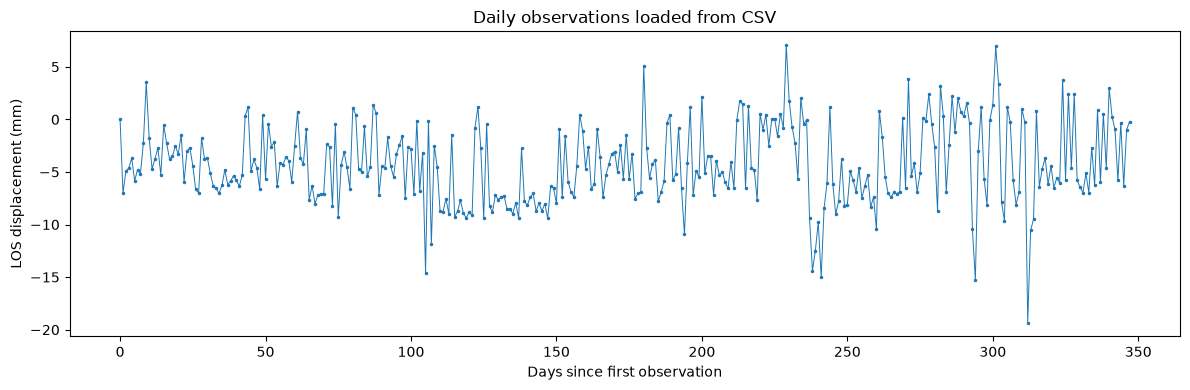

In [8]:
plt.rcParams['figure.facecolor'] = 'white'
plt.figure(figsize=(12, 4))
plt.plot(time, this_signal, '.-', markersize=3, linewidth=0.7)
plt.xlabel('Days since first observation')
plt.ylabel('LOS displacement (mm)')
plt.title('Daily observations loaded from CSV')
plt.tight_layout()
plt.show()


## Use the cleaned daily signal

Use the input observations directly. Standardization below uses only the training
segment, and forecasts are converted back to millimetres for plots and metrics.


In [9]:
assert len(time) == len(this_signal)


A one-step forecast is a **next-day forecast**; `window_size` is measured in days.


In [10]:
print(f"Signal shape: {this_signal.shape}; history: {window_size} days; forecast lead: 1 day")


Signal shape: (348,); history: 10 days; forecast lead: 1 day


In [11]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Make one-step examples: a history window and its next observation."""
    values = np.asarray(series, dtype=np.float32)
    if values.ndim != 1 or len(values) <= window_size:
        raise ValueError("Provide a 1D series longer than the input window.")
    windows = np.lib.stride_tricks.sliding_window_view(values, window_size + 1)
    dataset = tf.data.Dataset.from_tensor_slices(
        (windows[:, :-1].copy(), windows[:, -1].copy())
    )
    return dataset.shuffle(shuffle_buffer, seed=SEED).batch(batch_size).prefetch(1)


## Split the dataset chronologically

Use `train_fraction` of the observations for training and hold out the remainder.
The default 65% split gives 226 training days and 122 validation days for the
supplied 348-value file. Scaling is fitted on the training segment only.
The held-out segment is not used to choose the fixed training epoch count.


In [12]:
if not 0.0 < train_fraction < 1.0:
    raise ValueError("train_fraction must be between 0 and 1.")
split_time = int(train_fraction * len(this_signal))
if not window_size < split_time < len(this_signal):
    raise ValueError("The split must leave training windows and validation observations.")
time_train, time_valid = time[:split_time], time[split_time:]
x_train, x_valid = this_signal[:split_time], this_signal[split_time:]
train_mean = float(x_train.mean())
train_scale = max(float(x_train.std()), 1e-6)
x_train_scaled = (x_train - train_mean) / train_scale
print(f"Training: {len(x_train)} days; validation: {len(x_valid)} days")


Training: 226 days; validation: 122 days


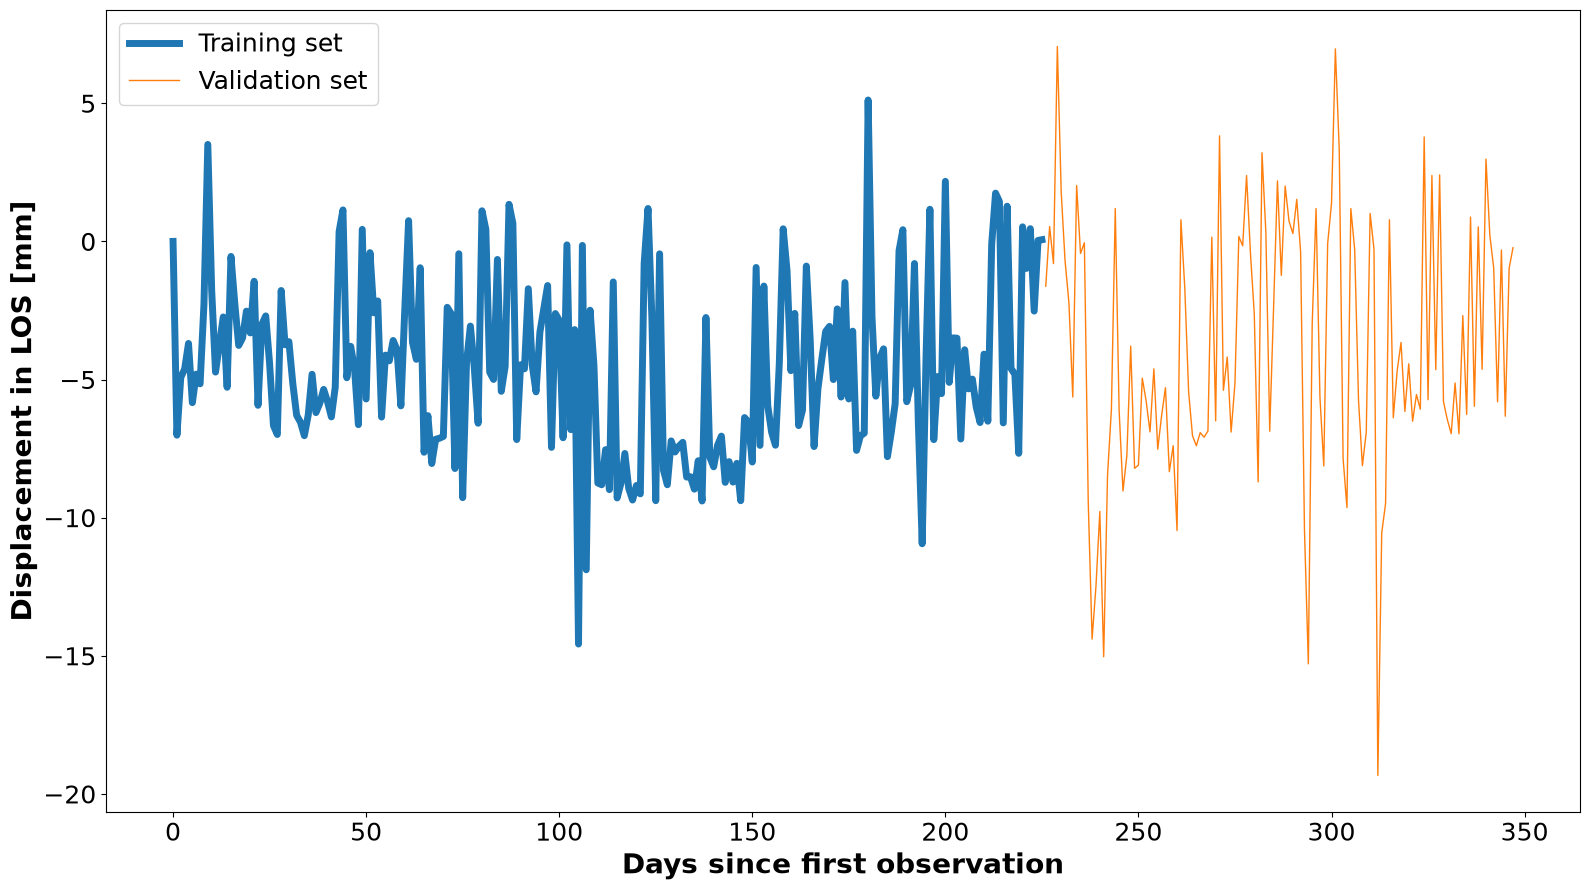

In [13]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, linewidth=5, label='Training set')
plt.plot(time_valid, x_valid, linewidth=1, label='Validation set')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first observation', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [14]:
train_set = windowed_dataset(x_train_scaled, window_size, batch_size, shuffle_buffer)


E0000 00:00:1790349540.564127   54136 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# The AI-part

## Build the Conv1D–LSTM model

The model predicts the next day's standardized displacement from `window_size`
past daily values. The architecture retains the two 64-unit LSTMs and output
multiplier. Building the model initializes new weights; training below is required.


In [15]:
# Reset states generated by Keras
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size, 1)),
    tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        padding="causal",
        activation="relu",
    ),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 20.),
])


Training starts from scratch; there is no saved-model dependency.


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train before predicting


Epoch 1/400


/media/hog/fringe/dev/env/py_general/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


7/7 - 3s - 447ms/step - loss: 1.3264
Epoch 2/400
7/7 - 0s - 11ms/step - loss: 0.9380
Epoch 3/400
7/7 - 0s - 11ms/step - loss: 0.9242
Epoch 4/400
7/7 - 0s - 11ms/step - loss: 0.9120
Epoch 5/400
7/7 - 0s - 10ms/step - loss: 0.9069
Epoch 6/400
7/7 - 0s - 11ms/step - loss: 0.9445
Epoch 7/400
7/7 - 0s - 10ms/step - loss: 0.8769
Epoch 8/400
7/7 - 0s - 10ms/step - loss: 0.9212
Epoch 9/400
7/7 - 0s - 10ms/step - loss: 0.9103
Epoch 10/400
7/7 - 0s - 10ms/step - loss: 0.9338
Epoch 11/400
7/7 - 0s - 11ms/step - loss: 0.9386
Epoch 12/400
7/7 - 0s - 10ms/step - loss: 0.8784
Epoch 13/400
7/7 - 0s - 10ms/step - loss: 0.8827
Epoch 14/400
7/7 - 0s - 10ms/step - loss: 0.8847
Epoch 15/400
7/7 - 0s - 10ms/step - loss: 0.8599
Epoch 16/400
7/7 - 0s - 10ms/step - loss: 0.9517
Epoch 17/400
7/7 - 0s - 10ms/step - loss: 0.8872
Epoch 18/400
7/7 - 0s - 10ms/step - loss: 0.8814
Epoch 19/400
7/7 - 0s - 10ms/step - loss: 0.8629
Epoch 20/400
7/7 - 0s - 10ms/step - loss: 0.8471
Epoch 21/400
7/7 - 0s - 10ms/step - loss

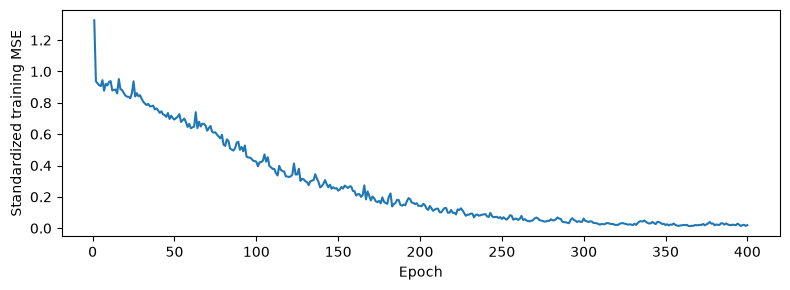

In [17]:
train_set_3d = train_set.map(
    lambda x, y: (x[..., tf.newaxis], y[..., tf.newaxis])
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
    loss="mse",
)
history = model.fit(train_set_3d, epochs=num_epochs, verbose=2)

plt.figure(figsize=(8, 3))
plt.plot(np.arange(1, num_epochs + 1), history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Standardized training MSE')
plt.tight_layout()
plt.show()


## Rolling next-day forecasts

The first input is `this_signal[split_time-window_size:split_time]` and predicts
observation `split_time`. Each later input contains the actual observations
available before its target day, including earlier validation observations.
Every prediction is plotted at its target day and converted back to millimetres.


In [18]:
def predict_windows(windows):
    windows = np.asarray(windows, dtype=np.float32)
    if windows.ndim != 2 or windows.shape[1] != window_size:
        raise ValueError(f"Expected [batch, {window_size}] windows.")
    inputs = ((windows - train_mean) / train_scale)[..., None]
    predictions = model(inputs, training=False).numpy().reshape(-1)
    return predictions * train_scale + train_mean

forecast_series = this_signal[split_time - window_size:]
forecast_windows = np.lib.stride_tricks.sliding_window_view(
    forecast_series, window_size + 1
)[:, :-1].copy()
results = predict_windows(forecast_windows)
assert results.shape == x_valid.shape


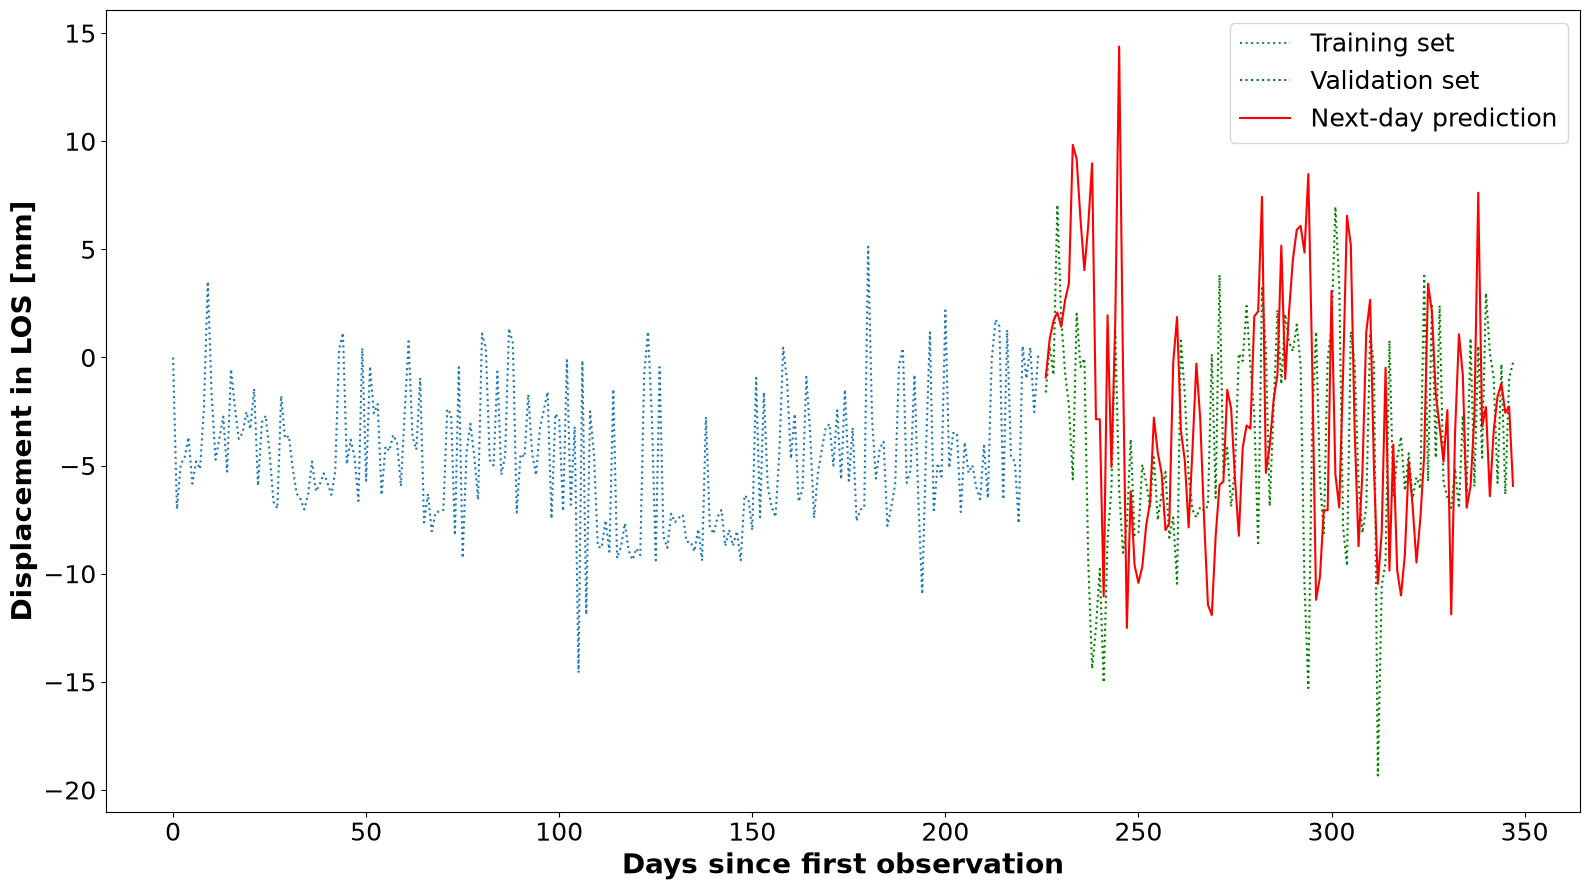

In [19]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, ':', label='Training set')
plt.plot(time_valid, x_valid, ':', color='green', label='Validation set')
plt.plot(time_valid, results,'-',color='red', label='Next-day prediction')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first observation', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

plt.tight_layout()
plt.show()


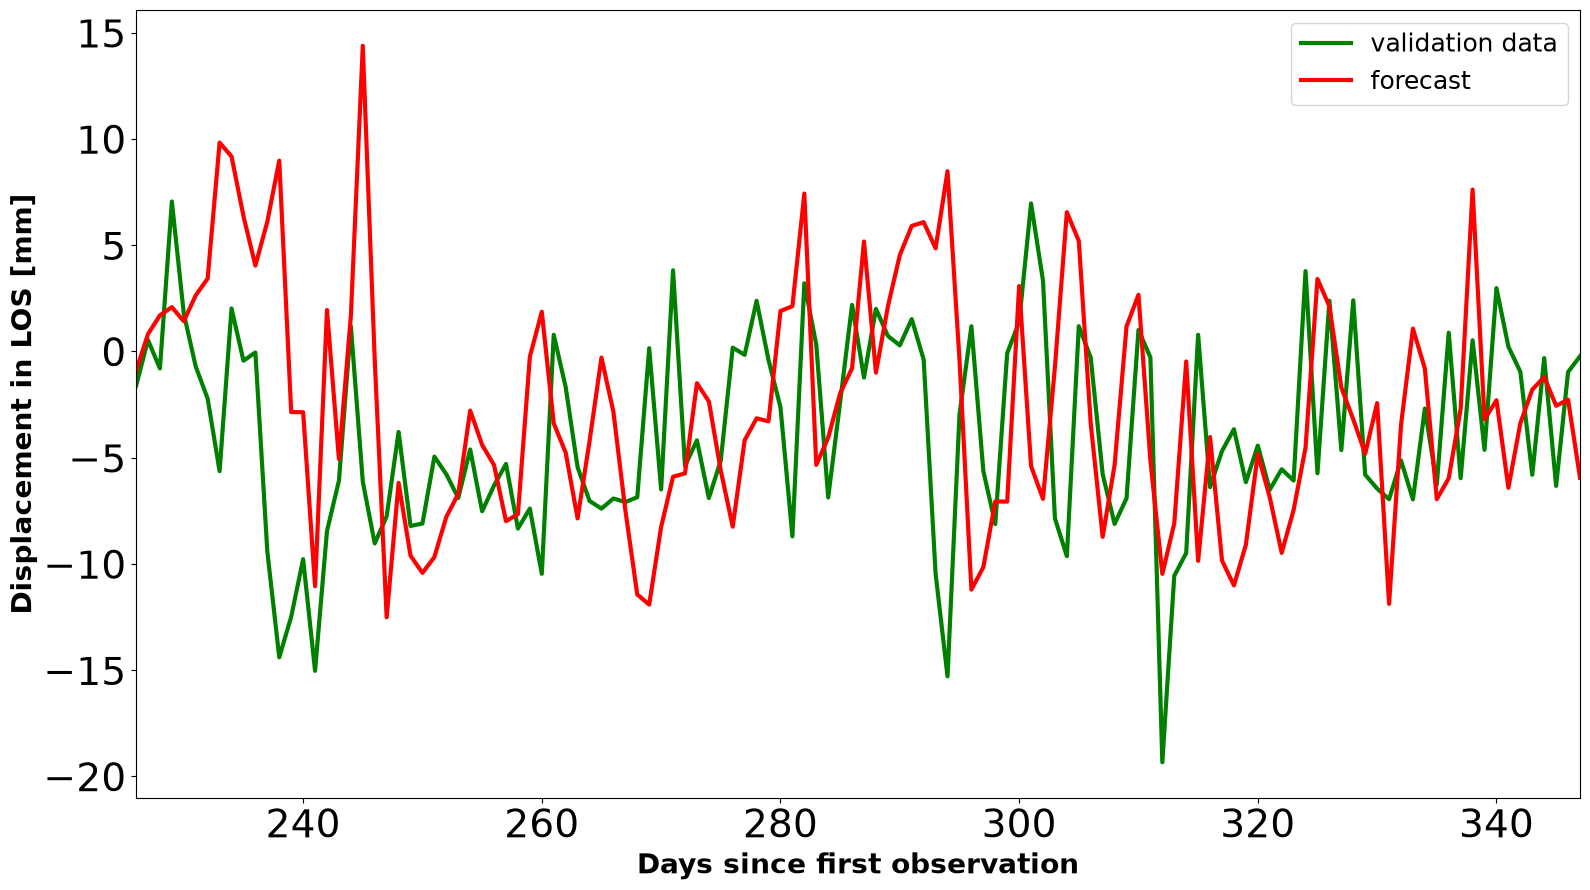

In [20]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train)
plt.plot(time_valid, x_valid, color='green', linewidth=3, label= 'validation data')
plt.plot(time_valid, results, color='red', linewidth=3, label='forecast')
plt.legend()
plt.xlim(time_valid[0], time_valid[-1])
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first observation', fontsize=20, fontweight='bold')
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [21]:
def forecast_metrics(actual, predicted):
    error = np.asarray(predicted) - np.asarray(actual)
    return {'MSE_mm2': float(np.mean(error ** 2)), 'MAE_mm': float(np.mean(np.abs(error)))}

persistence = this_signal[split_time - 1:-1]
rolling_metrics = pd.DataFrame({
    'Model one-step': forecast_metrics(x_valid, results),
    'Persistence one-step': forecast_metrics(x_valid, persistence),
}).T
rolling_metrics


,MSE_mm2,MAE_mm
Model one-step,47.658783,5.168220
Persistence one-step,29.680674,4.255512


## Recursive daily forecasts

Start with the last training window and feed each predicted displacement into the
next input. No validation observations enter this forecast. Each iteration advances
one day, so the number of validation values is also the forecast horizon in days.
Errors can accumulate over this longer horizon.


In [22]:
native_forecast = []
native_forecast_window = this_signal[split_time - window_size:split_time].copy()
for _ in range(len(x_valid)):
    next_value = float(predict_windows(native_forecast_window[None, :])[0])
    native_forecast.append(next_value)
    native_forecast_window = np.concatenate([
        native_forecast_window[1:], np.array([next_value], dtype=np.float32)
    ])
native_results = np.asarray(native_forecast, dtype=np.float32)
assert native_results.shape == x_valid.shape


In [23]:
mse = (native_results - x_valid) ** 2


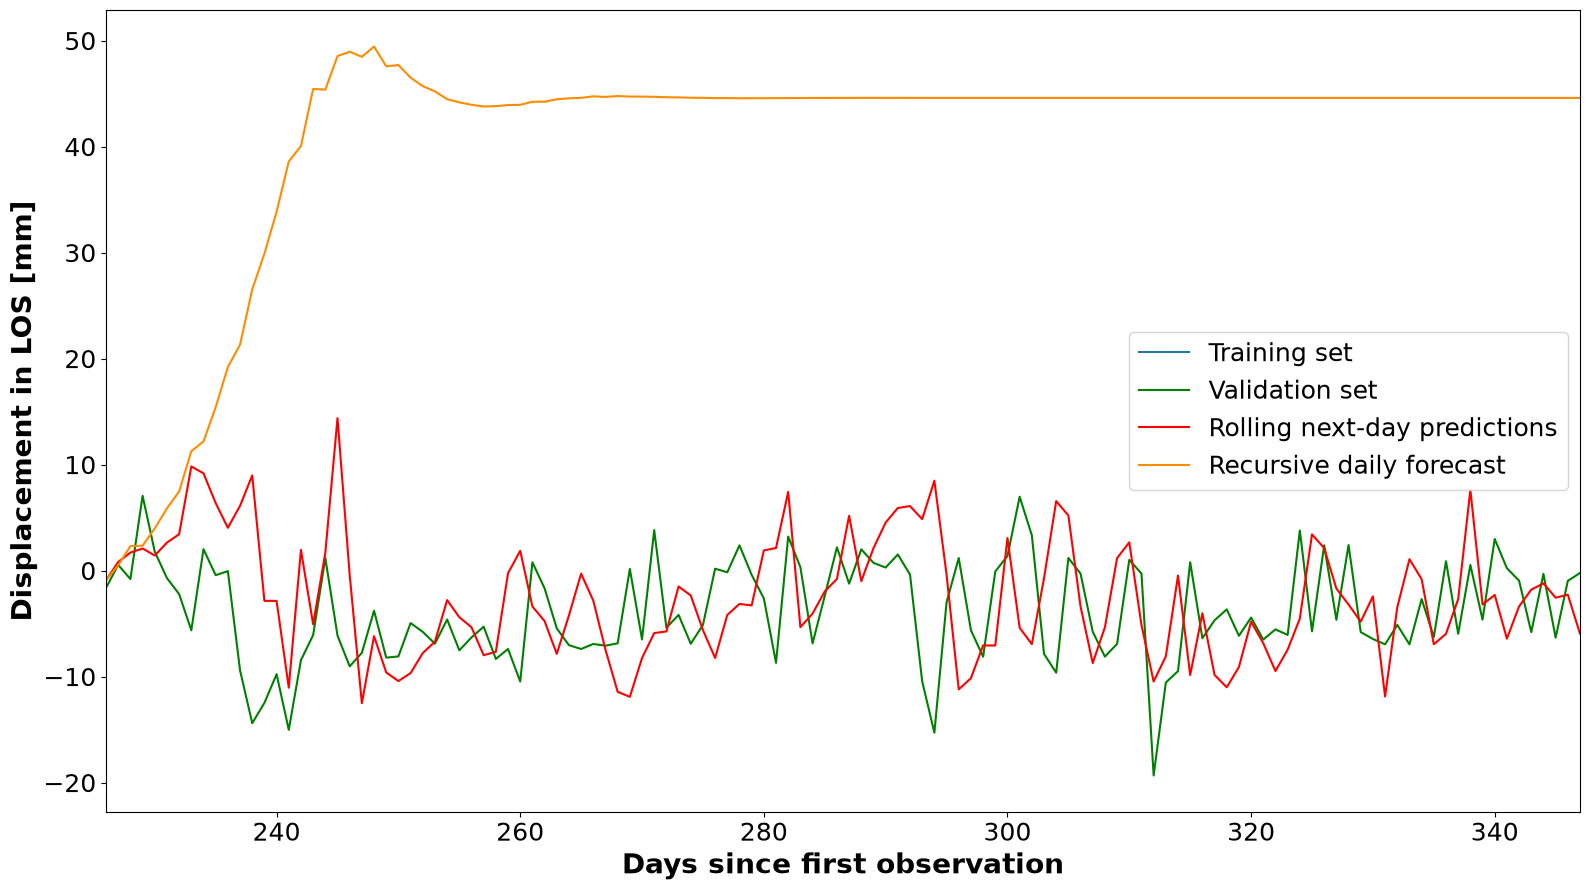

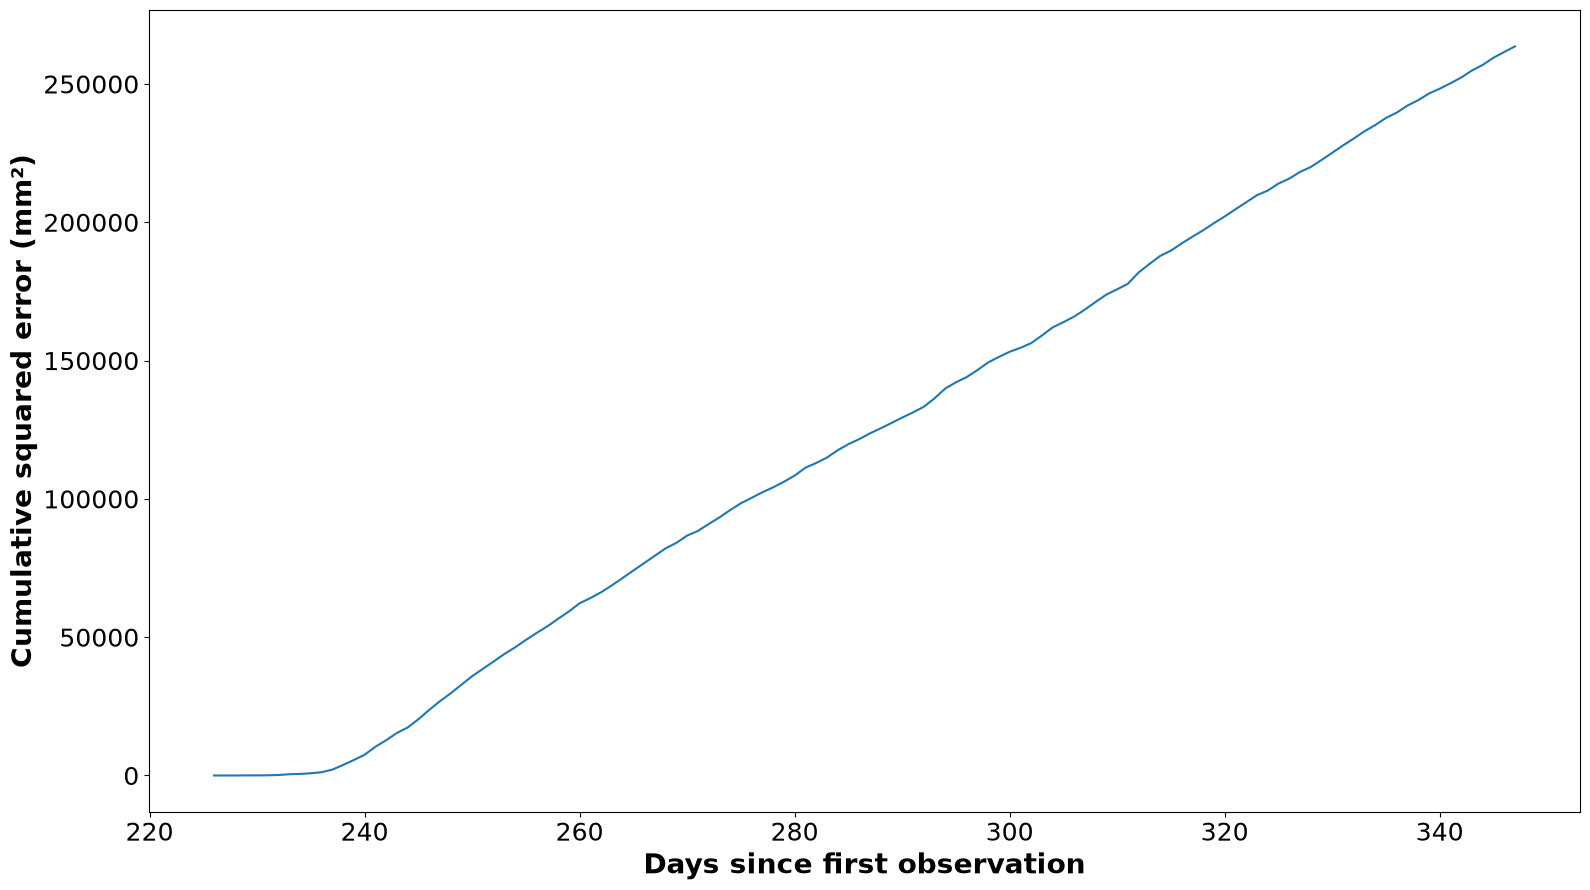

In [24]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, label='Training set')
plt.plot(time_valid, x_valid, color='green', label= 'Validation set')
plt.plot(time_valid, results, color='red', label='Rolling next-day predictions')
plt.plot(time_valid, native_results, color='darkorange', label='Recursive daily forecast')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first observation', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.xlim(time_valid[0], time_valid[-1])

plt.tight_layout()
plt.show()

plt.figure(figsize=[16,9])
plt.plot(time_valid, np.cumsum(mse))
plt.ylabel('Cumulative squared error (mm²)', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first observation', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18);
plt.yticks(fontsize=18);

plt.tight_layout()
plt.show()


Compare both forecasting modes with their persistence baselines. Rolling next-day
forecasts use newly available measurements; the recursive forecast uses predictions
after its fixed starting point. A smooth forecast alone does not establish skill.
Results describe this one daily series, not performance on other sites.


In [ ]:
recursive_persistence = np.full_like(x_valid, x_train[-1])
recursive_metrics = pd.DataFrame({
    'Model recursive': forecast_metrics(x_valid, native_results),
    'Persistence fixed origin': forecast_metrics(x_valid, recursive_persistence),
}).T
recursive_metrics
